# 1. Import Data

In [19]:
import pandas as pd
import numpy as np
pd.set_option('display.max_column', None)
pd.set_option('display.max_row', None)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("../Datasets/Raw/Telco_customer_churn_merged.csv")

# 2. Exploratory Data Analysis and Feature Engineering

## 2.1 Head, Info, and Describe

In [21]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churn Label,Population
0,8779-QRDMV,Male,78,No,Yes,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,0,1,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,Yes,68701
1,7495-OOKFY,Female,74,No,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,1,8,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,Yes,55668
2,1658-BYGOY,Male,71,No,Yes,No,3,United States,California,Los Angeles,90065,34.108833,-118.229715,0,18,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,Yes,47534
3,4598-XLKNJ,Female,78,No,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,1,25,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,Yes,27778
4,4846-WHAFZ,Female,80,No,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,1,37,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,Yes,26265


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   str    
 4   Senior Citizen                     7043 non-null   str    
 5   Married                            7043 non-null   str    
 6   Number of Dependents               7043 non-null   int64  
 7   Country                            7043 non-null   str    
 8   State                              7043 non-null   str    
 9   City                               7043 non-null   str    
 10  Zip Code                           7043 non-null   int64  
 11  Latitude                           7043 non-null   float64
 12  Lon

In [23]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Population
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,22139.603294
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,21152.392837
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,11.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,2344.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,17554.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,36125.000000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,105285.000000


## 2.2 Data Distribution

In [24]:
df['Internet Type'] = df['Internet Type'].fillna('No Internet Service')
df.isna().sum().sum()

np.int64(0)

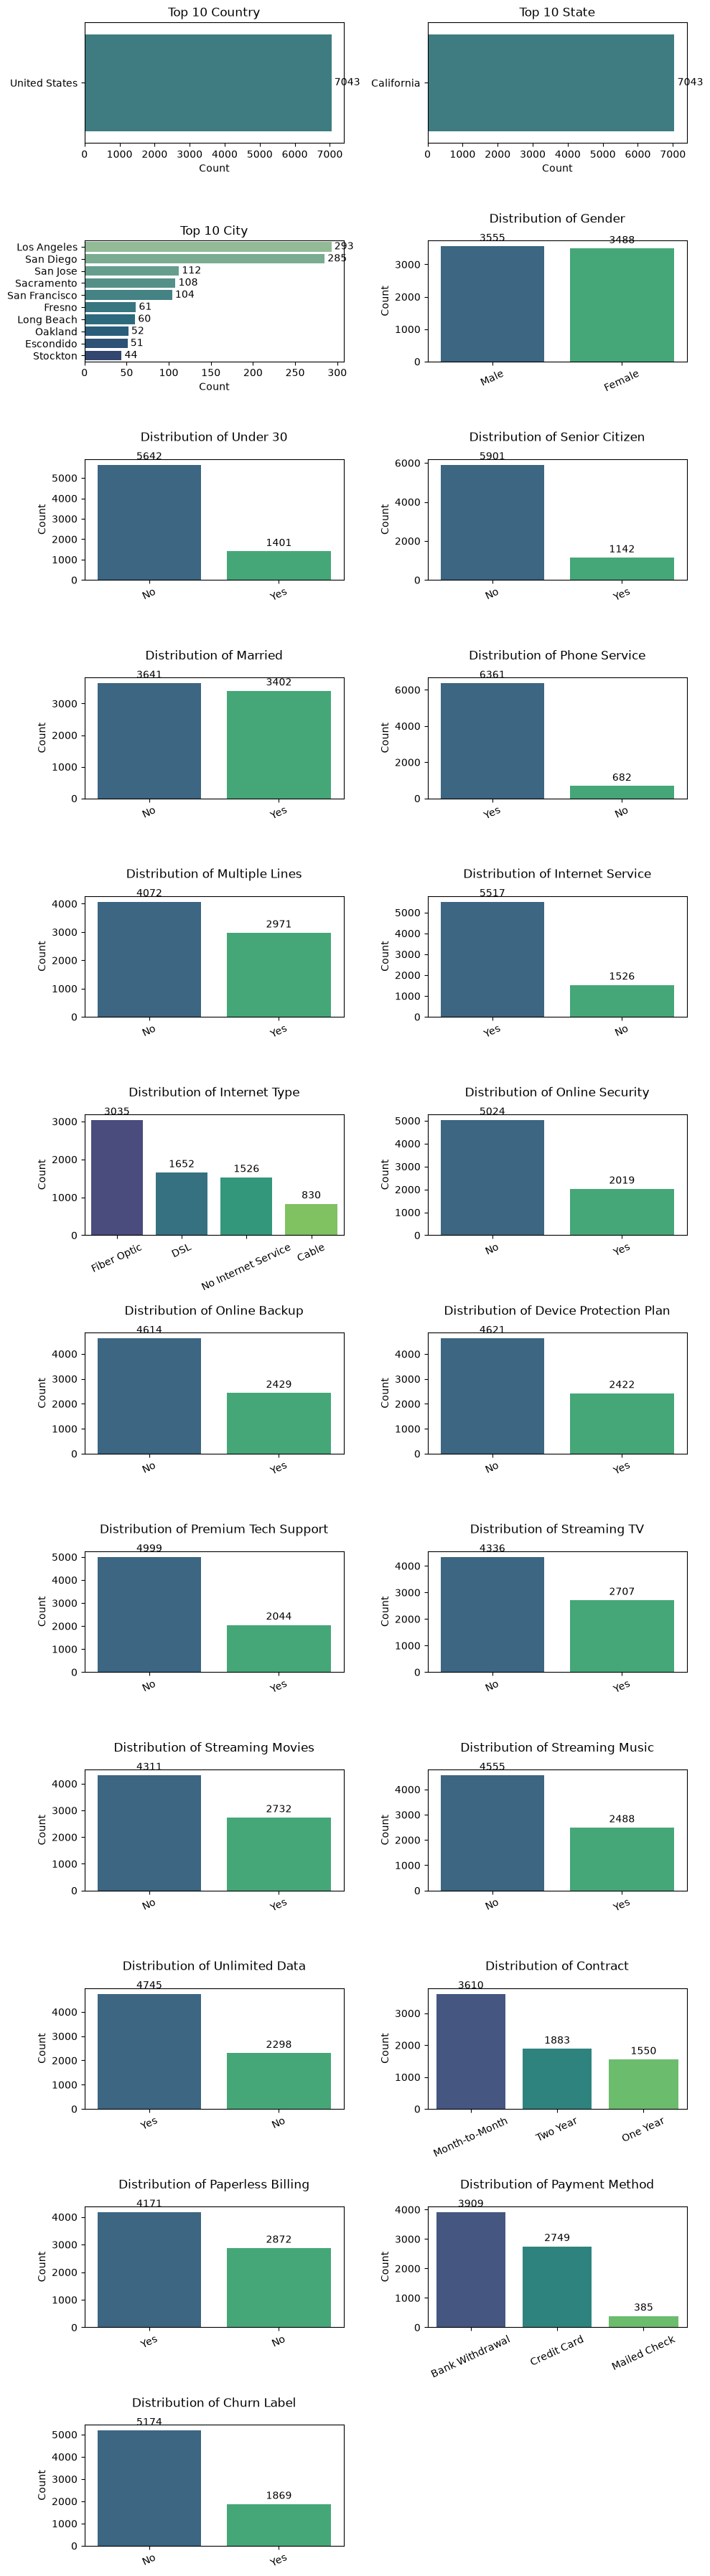

In [25]:
cat_cols = ['Country',
            'State',
            'City',
            'Gender',
            'Under 30',
            'Senior Citizen',
            'Married',
            'Phone Service',
            'Multiple Lines',
            'Internet Service',
            'Internet Type',
            'Online Security',
            'Online Backup',
            'Device Protection Plan',
            'Premium Tech Support',
            'Streaming TV',
            'Streaming Movies',
            'Streaming Music',
            'Unlimited Data',
            'Contract',
            'Paperless Billing',
            'Payment Method',
            'Churn Label']

fig, axes = plt.subplots(12, 2, figsize=(10, 36))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in ['City', 'State', 'Country']:
        top_10 = df[col].value_counts().sort_values(ascending=False).nlargest(10).index
        sns.countplot(df[df[col].isin(top_10)], y=col, ax=axes[i], palette='crest', order=top_10)
        axes[i].set_title(f'Top 10 {col}')
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel('')

    else:
        sns.countplot(df, x=col, ax=axes[i], palette='viridis', order=df[col].value_counts().sort_values(ascending=False).index)
        axes[i].set_title(f'Distribution of {col}', y=1.1)
        axes[i].tick_params(axis='x', rotation=25)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Count')

    for p in axes[i].containers:
        axes[i].bar_label(p, fmt='%d', padding=3)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
    

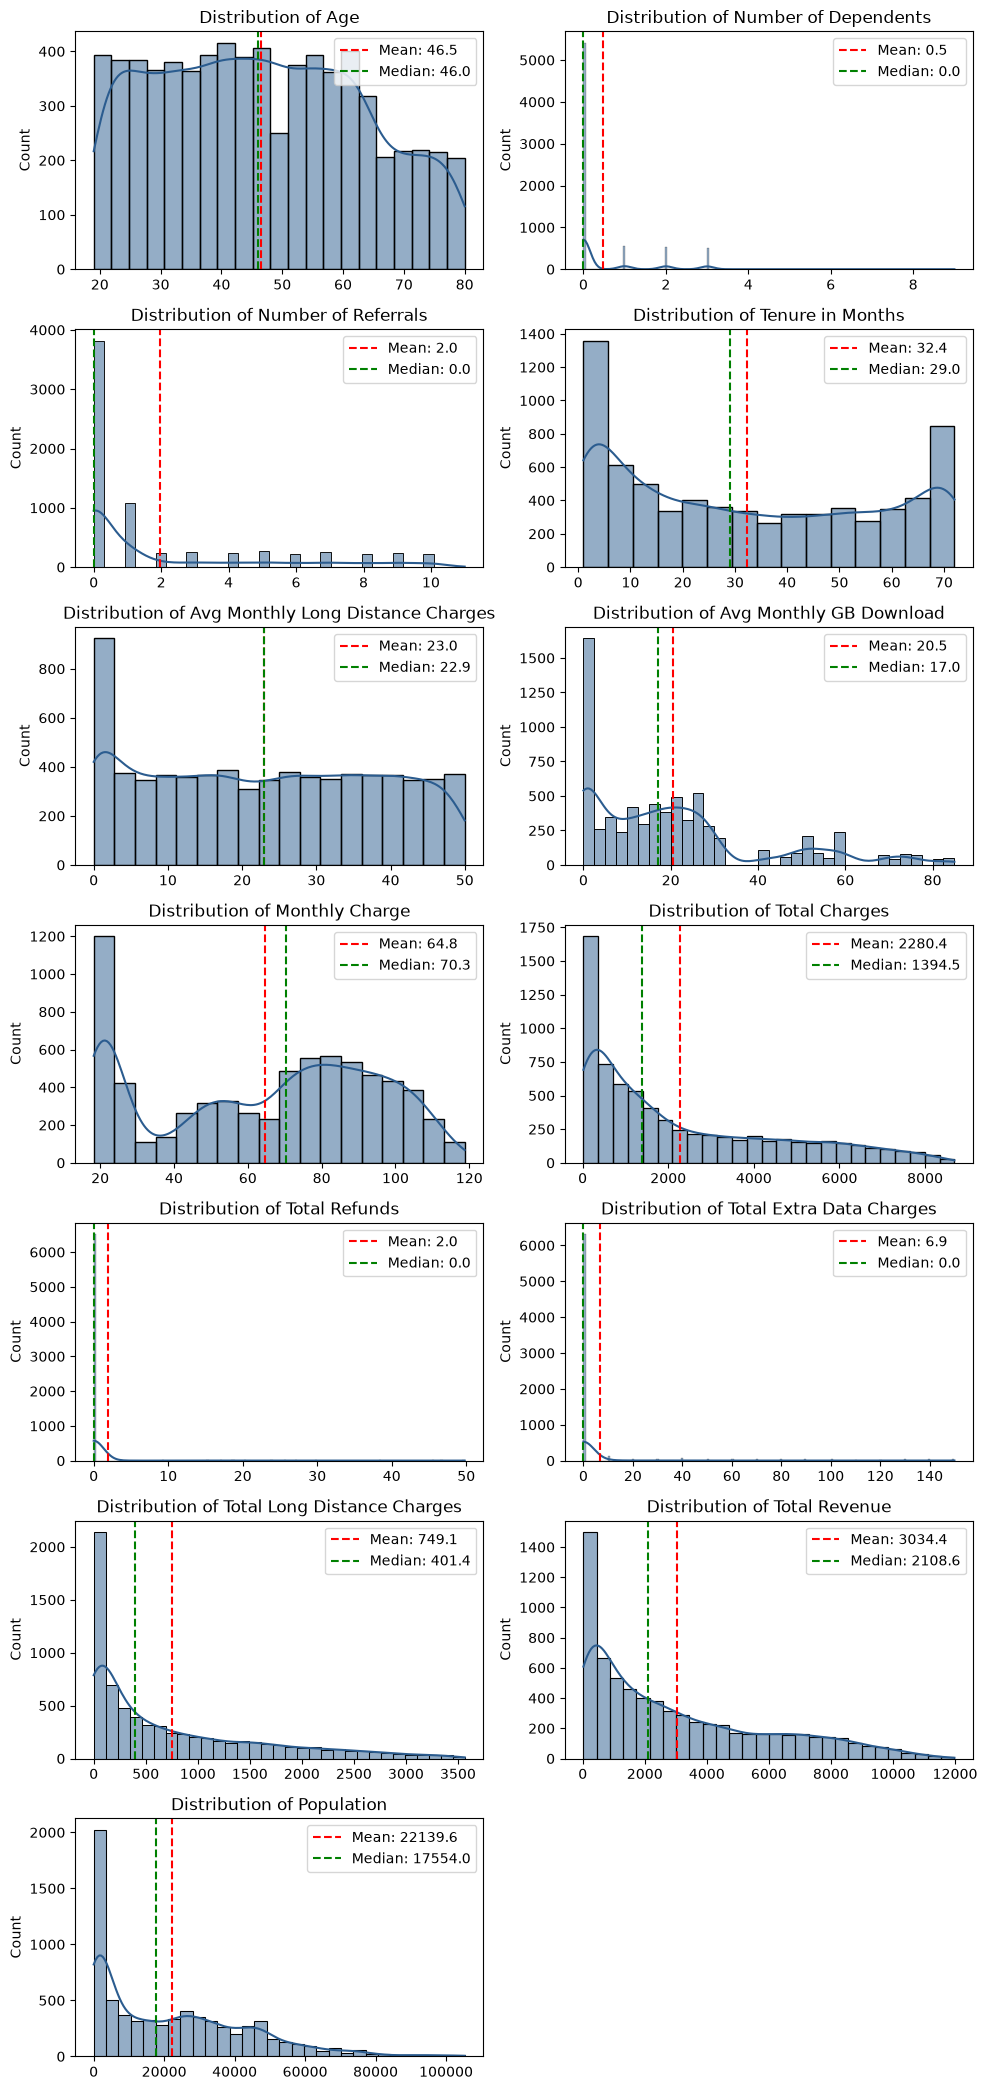

In [26]:
num_cols = ['Age',
            'Number of Dependents',
            'Number of Referrals',
            'Tenure in Months',
            'Avg Monthly Long Distance Charges',
            'Avg Monthly GB Download',
            'Monthly Charge',
            'Total Charges',
            'Total Refunds',
            'Total Extra Data Charges',
            'Total Long Distance Charges',
            'Total Revenue',
            'Population']

fig, axes = plt.subplots(7, 2, figsize=(10, 21))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df, x=col, kde=True, color="#2b5c8f", ax=axes[i])

    mean = df[col].mean()
    median = df[col].median()
    axes[i].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(loc='upper right')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [27]:
df['City'].nunique()

1106

In [28]:
df['City'].value_counts().sort_values(ascending=False)

City
Los Angeles               293
San Diego                 285
San Jose                  112
Sacramento                108
San Francisco             104
Fresno                     61
Long Beach                 60
Oakland                    52
Escondido                  51
Stockton                   44
Fallbrook                  43
Glendale                   40
Bakersfield                39
Temecula                   38
Riverside                  32
Berkeley                   32
Whittier                   30
Pasadena                   30
Anaheim                    28
Santa Barbara              28
Irvine                     28
San Bernardino             28
Modesto                    28
Inglewood                  25
Burbank                    25
Torrance                   25
Santa Monica               25
Santa Ana                  24
Santa Rosa                 24
Chula Vista                22
North Hollywood            20
Van Nuys                   20
Rancho Cucamonga           20
Garde

## 2.3 High-Risk Contrack

**Hypothesis:** Customers on Month-to-Month contracts have the flexibility to leave whenever they want. Do they cancel more frequently when their monthly bills cross a certain financial threshold compared to those on 1-year or 2-year contracts?

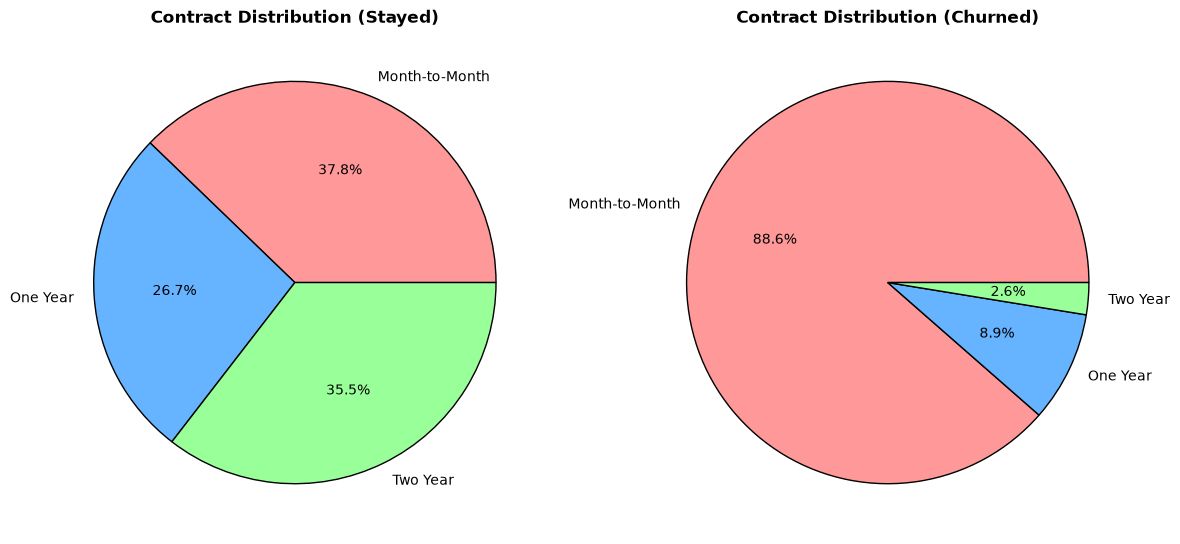

In [33]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']

axes[0].pie(
    contract_churn['No'],
    labels=contract_churn.index,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title('Contract Distribution (Stayed)', fontweight='bold')

axes[1].pie(
    contract_churn['Yes'],
    labels=contract_churn.index,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Contract Distribution (Churned)', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** Pie chart tells us that churners are dominated by *Month-to-Month* contract around **88.6%**. This indicates that *Month-to-Month* customers are highly flexible to leave. In the other hand, Stayed Customers are more uniform, separated from *Month-to-Month* and *Two Year*

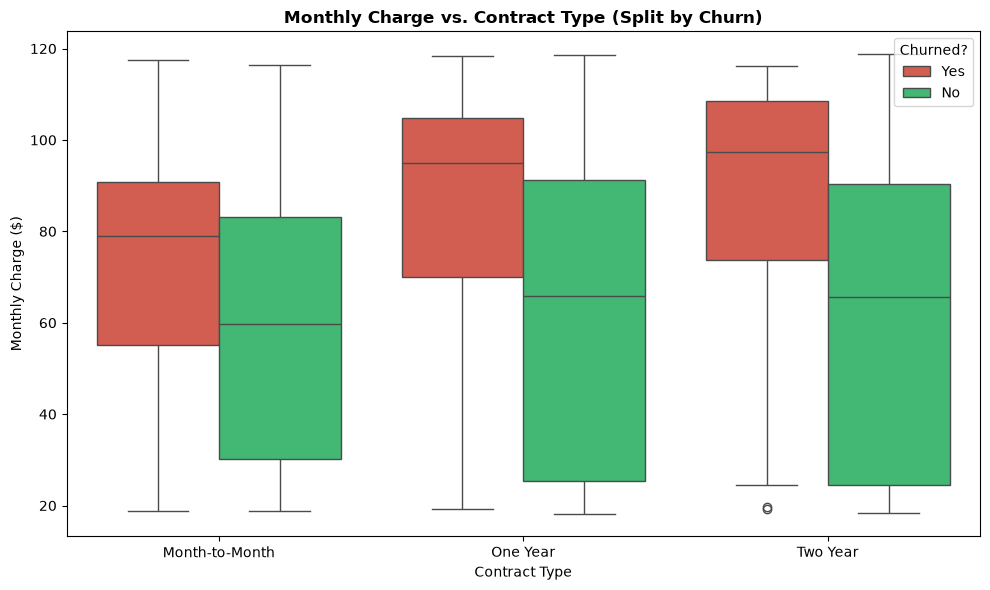

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    df,
    x='Contract',
    y='Monthly Charge',
    hue='Churn Label',
    palette={'Yes': '#e74c3c', 'No': '#2ecc71'}
)

plt.title('Monthly Charge vs. Contract Type (Split by Churn)', fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charge ($)')
plt.legend(title='Churned?', loc='upper right')
plt.tight_layout()
plt.show()

**Insight:** Most of the churner are leaving when their pay bills are expensive. For *Month-to-Month*, customers tend to leave when their bills are around 80$. The other side, customers with *One Year* and *Two Year* contract usually don't easily break the long-term contract, unless their bills are around 90$ more expensive than *Month-to-Month* contract

## 2.4 Vulnerable Demographic

**Hypothesis:** Do younger customers rely on the service more (or less) than older customers?

In [32]:
df['30 to 64'] = np.where(
    (df['Under 30'] == 'No') & (df['Senior Citizen'] == 'No'),
    'Yes',
    'No'
)

df['30 to 64'].head()

0    No
1    No
2    No
3    No
4    No
Name: 30 to 64, dtype: str

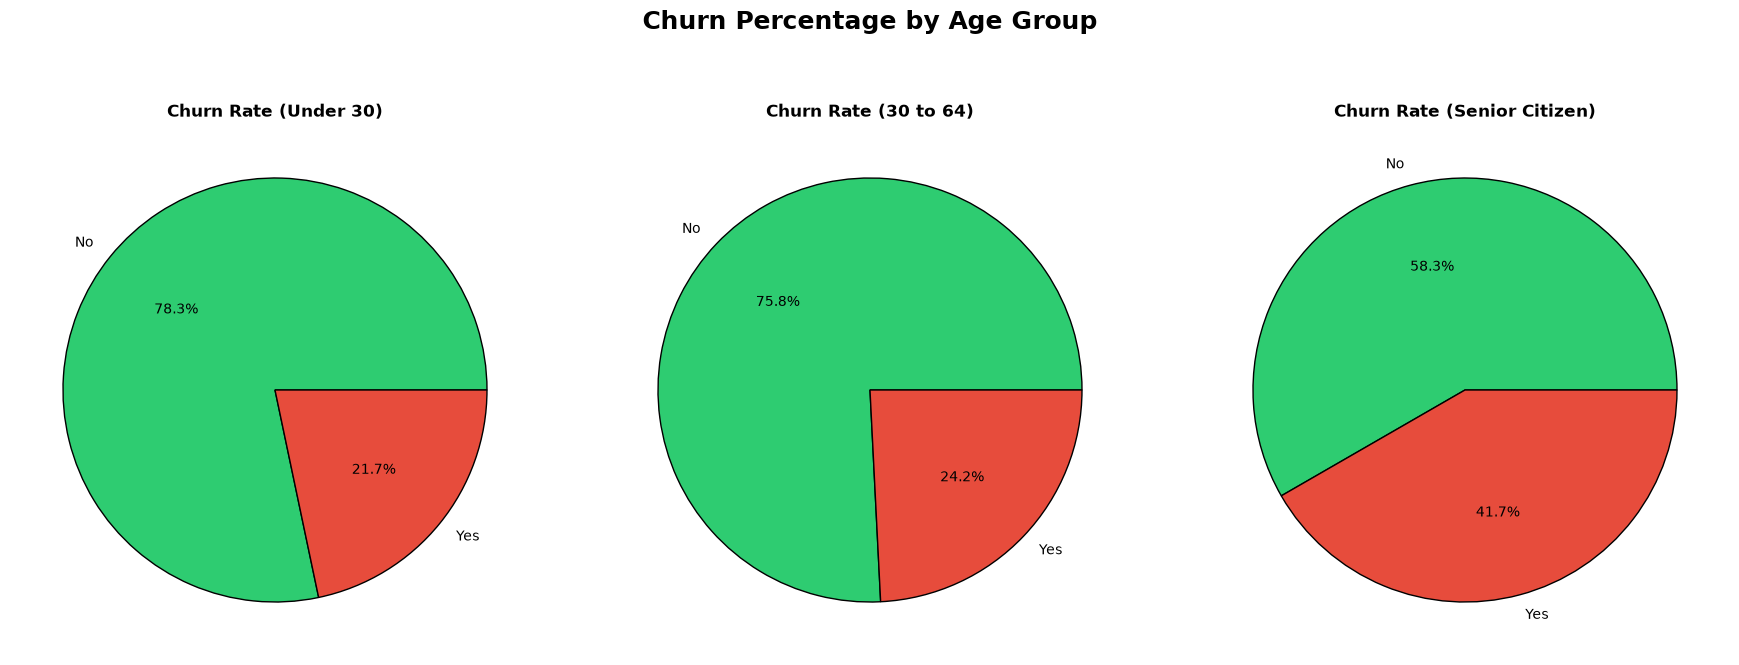

In [50]:
conditions = [
    df['Under 30'] == 'Yes',
    df['30 to 64'] == 'Yes',
    df['Senior Citizen'] == 'Yes'
]
age_group = ['Under 30', '30 to 64', 'Senior Citizen']
df['Age Group'] = np.select(
    conditions,
    age_group,
    default='Unknown'
)

age_churn = pd.crosstab(df['Age Group'], df['Churn Label']).T
age_churn = age_churn.reindex(['No', 'Yes'])
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, group in enumerate(age_group):
    axes[i].pie(
        age_churn[group],
        labels=age_churn.index,
        autopct='%1.1f%%',
        colors=colors,
        wedgeprops={'edgecolor': 'black'}
    )
    axes[i].set_title(f'Churn Rate ({group})', fontweight='bold')

plt.suptitle('Churn Percentage by Age Group', fontsize=18, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

df = df.drop(['Age Group'], axis=1)

**Insight:** While the younger and middle-aged demographics have a churn rate of around 21% to 24%, the *Senior Citizen* churn rate spikes to **41.7%**. This means that nearly half of the senior demographic is leaving the company. Interestingly, both group *Under 30* and *30 to 64* maintain a solid retention rate of around 75% to 78%, indicating that customers don't slowly get more likely to leave as they age.

**New Hypothesis:** Are their household size trigerring their churning?

In [53]:
df['Household Size'] = 1 + (df['Married'] == 'Yes').astype(int) + df['Number of Dependents']
df['Is Alone'] = np.where(
    df['Household Size'] == 1,
    'Yes', 'No'
)

print(df['Household Size'].head())
print(df['Is Alone'].head())

0    1
1    3
2    4
3    3
4    3
Name: Household Size, dtype: int64
0    Yes
1     No
2     No
3     No
4     No
Name: Is Alone, dtype: str


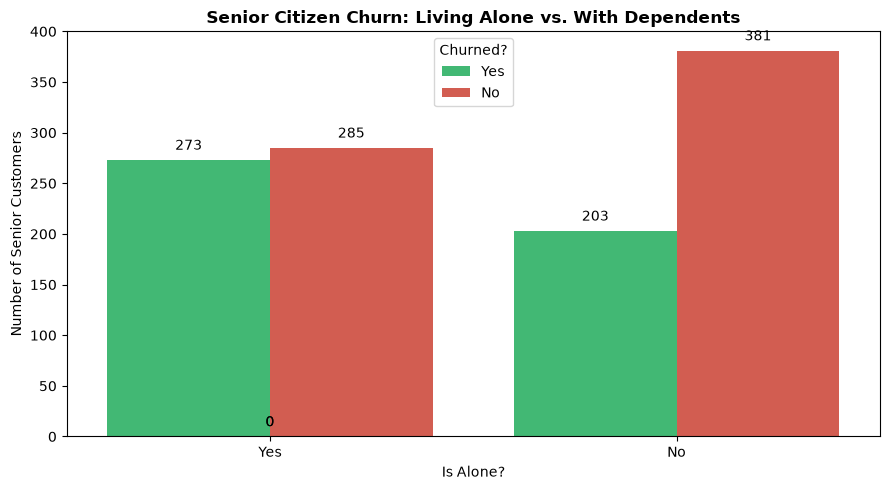

In [ ]:
senior_df = df[df['Senior Citizen']=='Yes']

plt.figure(figsize=(9, 5))
ax = sns.countplot(
    senior_df,
    x='Is Alone',
    hue='Churn Label',
    palette={'Yes': '#2ecc71', 'No': '#e74c3c'}
)

plt.title('Senior Citizen Churn: Living Alone vs. With Dependents', fontweight='bold')
plt.xlabel('Is Alone?')
plt.ylabel('Number of Senior Customers')
plt.legend(title='Churned?', loc='upper center')

for p in ax.patches:
    ax.annotate(
        text=f'{int(p.get_height())}',
        xy=(p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', 
        fontsize=10, color='black', xytext=(0, 5), 
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

**Insight:** Senior that living alone have a nearly **50%** churn rate. This group is highly vulnerable, likely due to a combination of fixed incomes and lack of at-home technical support. Besides, when they live with others (like a spouse or younger dependents), the presence of other people using internet or phone lines drastically reduces the likelihood that the senior will cancel the service

## 2.5 Payment Friction

**Hypothesis:** Does the way a person pays their bill affect how long they stay? Automatic payments require zero effort, while manual checks or bank transfers require the customer to actively pay every month.

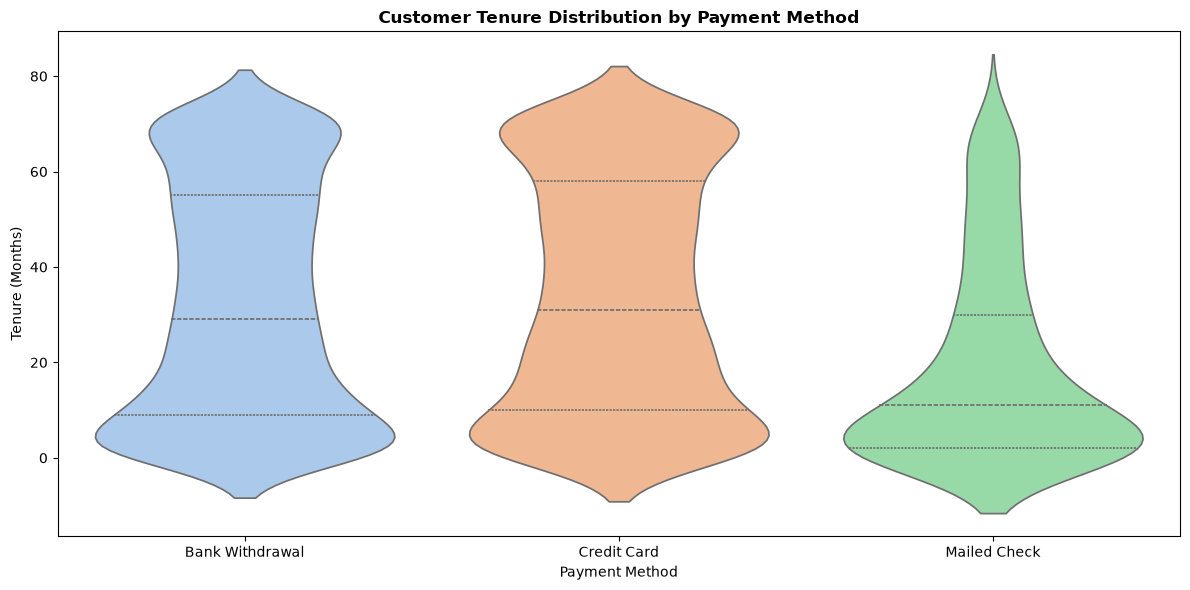

In [48]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    df,
    x='Payment Method',
    y='Tenure in Months',
    palette='pastel',
    inner='quartile'
)

plt.title('Customer Tenure Distribution by Payment Method', fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

**Insight:** The buttom bulge of green violin indicates that the vast majority of customers who pay by *Mailed Check* have extremely short tenures (mostly under 10-15 months). However, the other methods (*Bank Withdrawal* and *Credit Card*) show two bulges at the bottom and top. These shape reveal that customers using these method fall into two main campus: those who churn immediately and those who stay for a very long time (around more than 65 months). This indicates that manual payment method (*Mailed Check*) is highly correlated with early churn, while the automatic one (*Bank Withdrawal* and *Credit Card*) perform equally well at maintaining high-tenure customers.